# Seismic Event Prediction: Feature Engineering & Modeling Strategy

## 📌 Project Overview
This notebook focuses on the **predictive modeling** phase of the Balmatt Geothermal Project.
The goal is to predict induced seismicity events in the next 7 days based on operational data.

## ⚙️ Methodology
We employ a **Time-Series Mixture of Experts (MoE)** approach:
1.  **Regime Detection:** Identify distinct physical operating regimes using Change Point Detection.
2.  **Gating:** Use K-Means clustering to route incoming data points to specific "Expert" models based on flow and pressure dynamics.
3.  **Experts:** Train distinct Random Forest classifiers for different operational clusters.
4.  **Refinement:** Apply threshold tuning to maximize the F1-Macro score for rare event detection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Standard Library
import os
import warnings
from datetime import datetime, timedelta

# Data Manipulation & Mathematics
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from scipy.spatial import distance_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Scikit-Learn
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# Machine Learning - Other Libraries
import joblib
import ruptures as rpt
from imblearn.over_sampling import RandomOverSampler

# Configuration
warnings.filterwarnings('ignore')

## 2. Data Loading & Preprocessing
We load the resampled 5-minute operational data and the seismic catalog.
* **Derived Variables:** Calculating `net_flow` and `dT` (Temperature difference).
* **Time Sorting:** Ensuring all data is strictly chronological.

In [ ]:
operation = pd.read_csv('/content/drive/MyDrive/Data/New/operational_resampled_5min.csv')

In [ ]:
# ---- operation (minute) ----
operation['recorded_at'] = pd.to_datetime(operation['recorded_at'])
operation = operation.sort_values('recorded_at').set_index('recorded_at')

In [ ]:
# Data
seismics  = pd.read_csv('/content/drive/MyDrive/Data/seismic_events.csv')

# ---- operation (minute) ----
operation['recorded_at'] = pd.to_datetime(operation['recorded_at'])
operation = operation.sort_values('recorded_at').set_index('recorded_at')



# ---- seismics ----
seismics['occurred_at'] = pd.to_datetime(seismics['occurred_at'])
seismics = seismics.sort_values('occurred_at')


In [ ]:


# --- helper ---
def existing(cols, df):
    return [c for c in cols if c in df.columns]

# --- create net_flow, dT_prod_inj variable ---
if 'net_flow' not in operation.columns and {'inj_flow', 'prod_flow'} <= set(operation.columns):
    operation['net_flow'] = operation['inj_flow'] - operation['prod_flow']

if 'dT_prod_inj' not in operation.columns and {'prod_temp', 'inj_temp'} <= set(operation.columns):
    operation['dT_prod_inj'] = operation['prod_temp'] - operation['inj_temp']


In [ ]:
flow_cols    = ['inj_flow', 'basin_flow', 'prod_flow', 'net_flow']
press_cols   = ['inj_whp', 'inj_ap', 'prod_whp']
temp_cols    = ['inj_temp', 'prod_temp', 'dT_prod_inj']
energy_cols  = ['inj_energy', 'cooling_energy']
binary_cols  = ['is_producing']  # 0/1

cum_cols = existing(
    ['cum_volume', 'cum_inj_energy', 'cum_cooling_energy'],
    operation
)

# filter variable existing in dataset
base_cols = existing(
    flow_cols + press_cols + temp_cols + energy_cols + binary_cols,
    operation
)


## 3. Regime Change Detection
Geothermal operations shift between injection, shut-in, and production phases.
We use the **`ruptures`** library (Change Point Detection) to identify structural breaks in the time series (`net_flow`, `inj_ap`).
* This creates a `regime` label used to filter data later.

In [ ]:
pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import ruptures as rpt
from sklearn.preprocessing import StandardScaler

def detect_change_points_fast(
    df,
    cols,
    n_bkps=3,
    model="l2",
    max_points=10000
):
    df = df.sort_index()
    data = df[cols].dropna()

    if len(data) > max_points:
        step = len(data) // max_points + 1
        data = data.iloc[::step]

    scaler = StandardScaler()
    X = scaler.fit_transform(data.values)

    algo = rpt.Binseg(model=model).fit(X)
    bkp_indices = algo.predict(n_bkps=n_bkps)

    timestamps = data.index
    change_times = [timestamps[i-1] for i in bkp_indices[:-1]]
    return change_times, data


In [ ]:
cols = ['net_flow', 'dT_prod_inj', 'inj_ap']

change_times, data_used = detect_change_points_fast(
    operation,
    cols=cols,
    n_bkps=5,
    model="l2",
    max_points=50000
)

print("Change-points for variable:", cols)
for t in change_times:
    print(t)


Change-points for variable: ['net_flow', 'dT_prod_inj', 'inj_ap']
2021-09-21 13:05:00
2022-11-18 11:05:00
2024-01-05 05:20:00
2025-02-25 09:50:00
2025-06-20 06:05:00


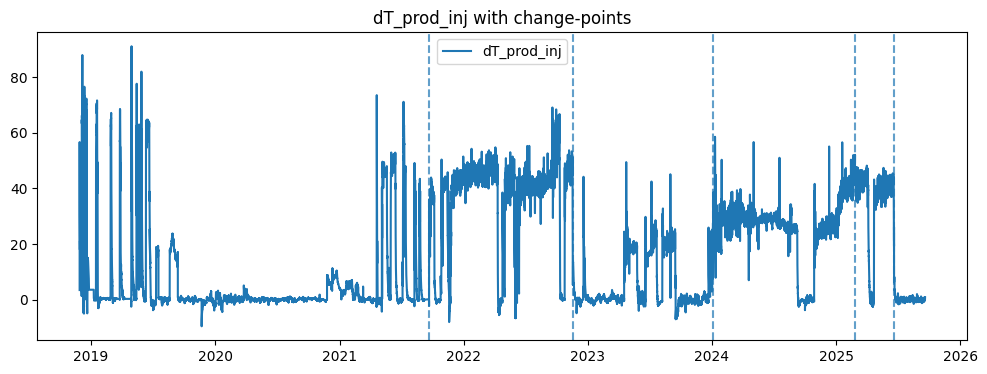

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(operation.index, operation['dT_prod_inj'], label='dT_prod_inj')

for t in change_times:
    ax.axvline(t, linestyle="--", alpha=0.7)

ax.legend()
ax.set_title("dT_prod_inj with change-points")
plt.show()

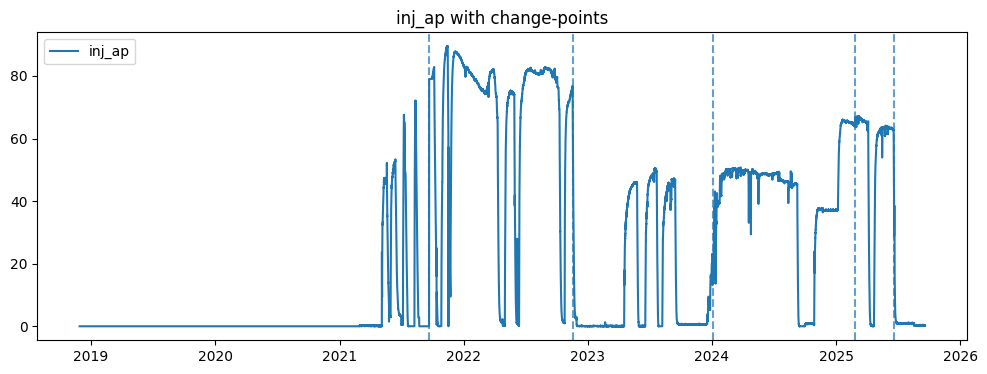

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(operation.index, operation['inj_ap'], label='inj_ap')

for t in change_times:
    ax.axvline(t, linestyle="--", alpha=0.7)

ax.legend()
ax.set_title("inj_ap with change-points")
plt.show()

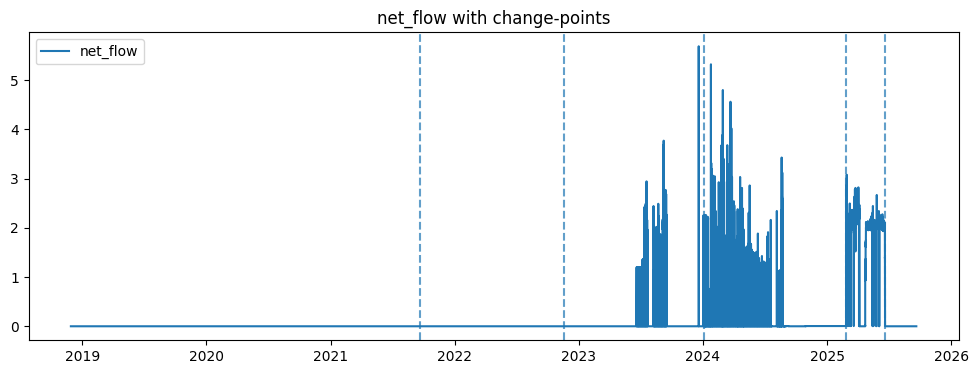

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(operation.index, operation['net_flow'], label='net_flow')

for t in change_times:
    ax.axvline(t, linestyle="--", alpha=0.7)

ax.legend()
ax.set_title("net_flow with change-points")
plt.show()

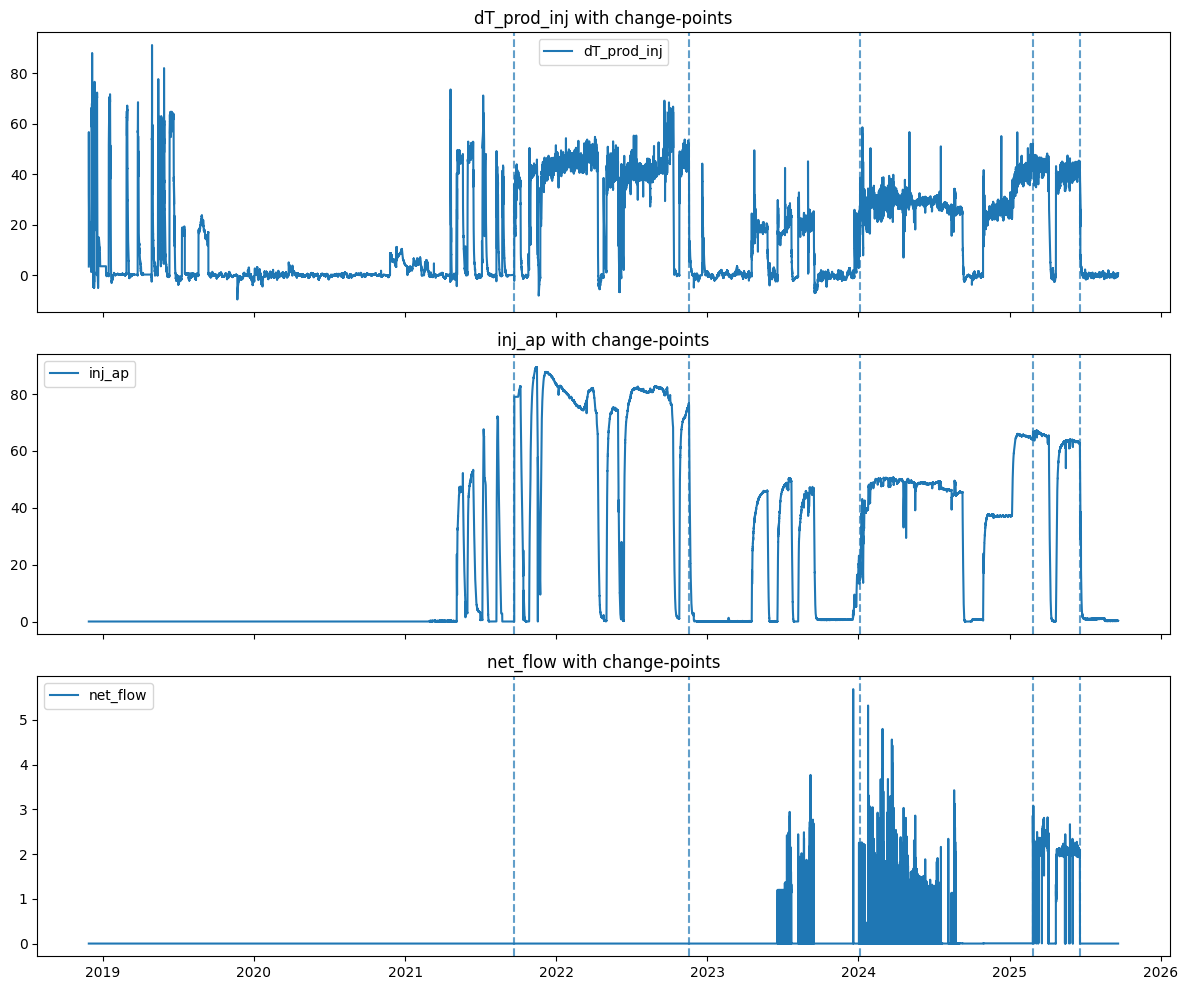

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1) dT_prod_inj
axes[0].plot(operation.index, operation['dT_prod_inj'], label='dT_prod_inj')
for t in change_times:
    axes[0].axvline(t, linestyle="--", alpha=0.7)
axes[0].set_title("dT_prod_inj with change-points")
axes[0].legend()

# 2) inj_ap
axes[1].plot(operation.index, operation['inj_ap'], label='inj_ap')
for t in change_times:
    axes[1].axvline(t, linestyle="--", alpha=0.7)
axes[1].set_title("inj_ap with change-points")
axes[1].legend()


# 4) net_flow
axes[2].plot(operation.index, operation['net_flow'], label='net_flow')
for t in change_times:
    axes[2].axvline(t, linestyle="--", alpha=0.7)
axes[2].set_title("net_flow with change-points")
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
cp_main = [
    pd.Timestamp("2021-09-21 13:05:00"),
    pd.Timestamp("2022-11-18 04:50:00"),
    pd.Timestamp("2024-01-05 11:35:00"),
    pd.Timestamp("2025-02-25 09:50:00"),
    pd.Timestamp("2025-06-20 06:05:00"),
]

boundaries = [operation.index.min()] + cp_main + [operation.index.max()]
labels = list(range(len(boundaries) - 1))   # 0,1,2,3,4,5

operation["regime"] = pd.cut(
    operation.index,
    bins=boundaries,
    labels=labels,
    right=False  # [start, end)
)


In [ ]:
operation.head()

,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,basin_flow,prod_flow,...,cnt_Mlt12_1d,cnt_M12_18_1d,cnt_Mge18_1d,cnt_Mlt12_3d,cnt_M12_18_3d,cnt_Mge18_3d,cnt_Mlt12_7d,cnt_M12_18_7d,cnt_Mge18_7d,max_mag_7days
recorded_at,,,,,,,,,,,,,,,,,,,,,
2018-11-28 11:20:00,0.0,3.473958,29.742170,18.670664,0.0,22.161097,5.309335,0.0,0.0,3.473958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.197
2018-11-28 11:25:00,0.0,25.510803,29.709707,11.027036,0.0,22.115342,5.307418,0.0,0.0,25.510803,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.197
2018-11-28 11:30:00,0.0,1.215181,29.675275,10.577293,0.0,22.089825,5.306586,0.0,0.0,1.215181,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.197
2018-11-28 11:35:00,0.0,8.490693,29.644622,10.619303,0.0,22.057563,5.306062,0.0,0.0,8.490693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.197
2018-11-28 11:40:00,0.0,0.057919,29.614782,10.622052,0.0,22.148908,5.306007,0.0,0.0,0.057919,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.197


## 4. Feature Engineering
We generate lagging features to capture the history of the reservoir:
* **Rolling Stats:** Mean, Max, Std Dev over 1, 3, and 7 days.
* **Trends:** Difference between current window and previous window.
* **Seismic Counts:** Number of past events in the last 1/3/7 days (merged using `merge_asof` to prevent leakage).

In [ ]:
time_windows = {
    '1d': '1D',
    '3d': '3D',
    '7d': '7D',
}

for col in base_cols:
    for win_name, win in time_windows.items():
        # mean in 1/3/7 day windows
        operation[f'{col}_mean_{win_name}'] = (
            operation[col].rolling(win, min_periods=1).mean()
        )
        # max tin 1/3/7 day windows
        operation[f'{col}_max_{win_name}'] = (
            operation[col].rolling(win, min_periods=1).max()
        )
        # std in 1/3/7 day windows
        operation[f'{col}_std_{win_name}'] = (
            operation[col].rolling(win, min_periods=1).std()
        )

# compare mean current 1D with previous mean 1D
for col in base_cols:
    if f'{col}_mean_1d' in operation.columns:
        operation[f'{col}_trend_1d'] = (
            operation[f'{col}_mean_1d'] -
            operation[f'{col}_mean_1d'].shift(freq='1D')
        )


In [ ]:
for col in cum_cols:
    operation[f'{col}_inc_1d'] = operation[col] - operation[col].shift(freq='1D')
    operation[f'{col}_inc_3d'] = operation[col] - operation[col].shift(freq='3D')
    operation[f'{col}_inc_7d'] = operation[col] - operation[col].shift(freq='7D')


In [ ]:
if 'is_producing' in operation.columns:
    operation['prod_ratio_1d'] = (
        operation['is_producing'].rolling('1D', min_periods=1).mean()
    )
    operation['prod_ratio_3d'] = (
        operation['is_producing'].rolling('3D', min_periods=1).mean()
    )

    switches = operation['is_producing'].diff().abs()
    operation['prod_switches_1d'] = switches.rolling('1D', min_periods=1).sum()
    operation['prod_switches_3d'] = switches.rolling('3D', min_periods=1).sum()


In [ ]:
seismics['is_M_lt_12']  = (seismics['magnitude'] < 1.2).astype(int)
seismics['is_M_12_18']  = ((seismics['magnitude'] >= 1.2) &
                           (seismics['magnitude'] < 1.8)).astype(int)
seismics['is_M_ge_18']  = (seismics['magnitude'] >= 1.8).astype(int)

seis_cum = seismics[['occurred_at', 'is_M_lt_12', 'is_M_12_18', 'is_M_ge_18']].copy()
seis_cum = seis_cum.sort_values('occurred_at')

seis_cum['cum_M_lt_12']  = seis_cum['is_M_lt_12'].cumsum()
seis_cum['cum_M_12_18']  = seis_cum['is_M_12_18'].cumsum()
seis_cum['cum_M_ge_18']  = seis_cum['is_M_ge_18'].cumsum()

cum_cols = ['cum_M_lt_12', 'cum_M_12_18', 'cum_M_ge_18']
cum_df = seis_cum[['occurred_at'] + cum_cols].copy()


In [ ]:
from pandas import merge_asof
times = pd.DataFrame({'t': operation.index})

windows = {
    '1d': pd.Timedelta('1D'),
    '3d': pd.Timedelta('3D'),
    '7d': pd.Timedelta('7D'),
}

for tag, delta in windows.items():
    # t (current)
    t_now = times[['t']].copy()
    # t - window
    t_prev = pd.DataFrame({'t': times['t'] - delta})

    # cum at t
    df_now = merge_asof(
        t_now,                                 # left
        cum_df.rename(columns={'occurred_at': 't'}),  # right
        on='t',
        direction='backward'
    )[cum_cols].fillna(0)

    # cum at t - window
    df_prev = merge_asof(
        t_prev,
        cum_df.rename(columns={'occurred_at': 't'}),
        on='t',
        direction='backward'
    )[cum_cols].fillna(0)

    diff = df_now - df_prev

    operation[f'cnt_Mlt12_{tag}']  = diff['cum_M_lt_12'].values
    operation[f'cnt_M12_18_{tag}'] = diff['cum_M_12_18'].values
    operation[f'cnt_Mge18_{tag}']  = diff['cum_M_ge_18'].values

# check
print(operation.filter(like='cnt_M').head())


                     cnt_Mlt12_1d  cnt_M12_18_1d  cnt_Mge18_1d  cnt_Mlt12_3d  \
recorded_at                                                                    
2018-11-28 11:20:00           0.0            0.0           0.0           0.0   
2018-11-28 11:25:00           0.0            0.0           0.0           0.0   
2018-11-28 11:30:00           0.0            0.0           0.0           0.0   
2018-11-28 11:35:00           0.0            0.0           0.0           0.0   
2018-11-28 11:40:00           0.0            0.0           0.0           0.0   

                     cnt_M12_18_3d  cnt_Mge18_3d  cnt_Mlt12_7d  cnt_M12_18_7d  \
recorded_at                                                                     
2018-11-28 11:20:00            0.0           0.0           0.0            0.0   
2018-11-28 11:25:00            0.0           0.0           0.0            0.0   
2018-11-28 11:30:00            0.0           0.0           0.0            0.0   
2018-11-28 11:35:00            0.0

In [ ]:
operation.head()

,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,basin_flow,prod_flow,...,data_point_count,magnitude_bin_7days,no_event_7days,mag_lt_1_2_7days,mag_1_2_1_8_7days,mag_gt_1_8_7days,count_prev_7days,net_flow,dT_prod_inj,regime
recorded_at,,,,,,,,,,,,,,,,,,,,,
2018-11-28 11:20:00,0.0,3.473958,29.742170,18.670664,0.0,22.161097,5.309335,0.0,0.0,3.473958,...,1,1,0,1,0,0,0,0.0,3.490433,0
2018-11-28 11:25:00,0.0,25.510803,29.709707,11.027036,0.0,22.115342,5.307418,0.0,0.0,25.510803,...,1,1,0,1,0,0,0,0.0,11.088306,0
2018-11-28 11:30:00,0.0,1.215181,29.675275,10.577293,0.0,22.089825,5.306586,0.0,0.0,1.215181,...,1,1,0,1,0,0,0,0.0,11.512532,0
2018-11-28 11:35:00,0.0,8.490693,29.644622,10.619303,0.0,22.057563,5.306062,0.0,0.0,8.490693,...,1,1,0,1,0,0,0,0.0,11.438260,0
2018-11-28 11:40:00,0.0,0.057919,29.614782,10.622052,0.0,22.148908,5.306007,0.0,0.0,0.057919,...,1,1,0,1,0,0,0,0.0,11.526856,0


## 5. Target Generation
We define the prediction targets for a **7-day forward window**:
* `magnitude_bin_7days`: Multiclass target.
* `max_mag_7days`: Continuous target for regression.
* **Note:** We save the processed feature set as `roll_lag_feature_operation.csv` for reproducibility.

In [ ]:
label_col = 'magnitude_bin_7days'

# all columns name in operation
all_cols = operation.columns


def existing(cols, all_cols):
    return [c for c in cols if c in all_cols]

# 1) base variable + new variable
flow_cols    = ['inj_flow', 'basin_flow', 'prod_flow', 'net_flow']
press_cols   = ['inj_whp', 'inj_ap', 'prod_whp']
temp_cols    = ['inj_temp', 'prod_temp', 'dT_prod_inj']
energy_cols  = ['inj_energy', 'cooling_energy']
binary_cols  = ['is_producing','regime']

base_cols = existing(
    flow_cols + press_cols + temp_cols + energy_cols + binary_cols,
    all_cols
)

# 2) cumulative variable
cum_cols = existing(
    ['cum_volume', 'cum_inj_energy', 'cum_cooling_energy'],
    all_cols
)

# 3) Count seismics variable
seis_cnt_cols = [c for c in all_cols if c.startswith('cnt_M')]

allowed_prefixes = base_cols + cum_cols

feature_cols = []

for col in all_cols:
    if col == label_col:
        continue  # remove label

    # 1) keep base variable + new variable
    if col in base_cols or col in cum_cols:
        feature_cols.append(col)
        continue

    # 2) keep count seismics variable
    if col in seis_cnt_cols:
        feature_cols.append(col)
        continue

    # 3) keep rolling variable
    if any(col.startswith(pref + '_') for pref in allowed_prefixes):

        if any(suffix in col for suffix in ['_1d', '_3d', '_7d']):
            feature_cols.append(col)
        continue

# sort
feature_cols = sorted(list(dict.fromkeys(feature_cols)))

print("Number of features selected:", len(feature_cols))
print("15 first features:", feature_cols[:15])


Number of features selected: 165
15 first features: ['basin_flow', 'basin_flow_max_1d', 'basin_flow_max_3d', 'basin_flow_max_7d', 'basin_flow_mean_1d', 'basin_flow_mean_3d', 'basin_flow_mean_7d', 'basin_flow_std_1d', 'basin_flow_std_3d', 'basin_flow_std_7d', 'basin_flow_trend_1d', 'cnt_M12_18_1d', 'cnt_M12_18_3d', 'cnt_M12_18_7d', 'cnt_Mge18_1d']


In [ ]:
# ---- seismics ----
seismics['occurred_at'] = pd.to_datetime(seismics['occurred_at'])
seismics = seismics.sort_values('occurred_at').set_index('occurred_at')

print(type(seismics.index), seismics.index.dtype)
print("Seismics  range:", seismics.index.min(), "→", seismics.index.max())


<class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns]
Seismics  range: 2018-12-05 05:29:53.740000 → 2025-06-25 07:12:37


In [ ]:
# magnitude numeric
mag = pd.to_numeric(seismics['magnitude'], errors='coerce')

# s = t + 7 ngày
op_shift_index = pd.DatetimeIndex(operation.index + pd.Timedelta(days=7))

# timeline chung
all_times = mag.index.union(op_shift_index)
all_times = all_times.sort_values()

# reindex seismics lên timeline chung
mag_all = mag.reindex(all_times)

# rolling max 7 ngày lùi
mag_filled = mag_all.fillna(-np.inf).astype(float)
rolling_max = mag_filled.rolling('7D', min_periods=1).max()

# lấy max trong (t, t+7] tại s = t+7
max_mag_for_shift = rolling_max.reindex(op_shift_index)

# không có event trong 7 ngày → -5
max_mag_7days = max_mag_for_shift.replace(-np.inf, -5)

# gán vào operation
operation['max_mag_7days'] = max_mag_7days.to_numpy()

In [ ]:
operation.describe()

,phase,inj_flow,inj_whp,inj_temp,inj_ap,prod_temp,prod_whp,gt03_whp,basin_flow,prod_flow,...,cnt_Mlt12_1d,cnt_M12_18_1d,cnt_Mge18_1d,cnt_Mlt12_3d,cnt_M12_18_3d,cnt_Mge18_3d,cnt_Mlt12_7d,cnt_M12_18_7d,cnt_Mge18_7d,max_mag_7days
count,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,...,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,716312.000000,126322.000000
mean,6.959022,7.661831,23.231765,32.819838,23.911405,48.210610,19.576804,2.302844,0.199019,7.464812,...,0.148762,0.002412,0.000804,0.446286,0.007237,0.002412,1.041334,0.016886,0.005629,0.215460
std,5.441352,11.682962,31.062255,25.655521,30.388287,42.246549,22.137323,2.924066,0.546093,11.574595,...,0.893925,0.049057,0.028346,2.288632,0.084763,0.049057,4.638314,0.140170,0.074814,0.671438
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.700000
25%,0.530000,0.000000,0.000000,10.633369,0.000000,11.817859,1.599212,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.238972
50%,8.000000,0.000000,0.000000,19.650872,0.624851,20.473551,2.116218,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066822
75%,12.400000,11.879521,47.293079,61.962736,48.676166,89.607641,46.576086,5.315714,0.000000,11.345149,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.439904
max,13.300000,145.005835,115.569408,113.966869,89.473145,121.618074,53.214048,150.000000,5.687282,145.005835,...,20.000000,1.000000,1.000000,46.000000,1.000000,1.000000,84.000000,2.000000,1.000000,2.089400


In [ ]:
operation.to_csv('/content/drive/MyDrive/Data/New/roll_lag_feature_operation.csv')

In [ ]:
# multi class
y_multi = operation['magnitude_bin_7days'].astype(int)

# continuous
y_continuous = operation['max_mag_7days']

# binary class
y_binary = (y_multi > 0).astype(int)


# Train with regime change
```

                    ┌──────────────────────────────────────────┐
                    │               TRAINING STAGE             │
                    └──────────────────────────────────────────┘
                                   │
                                   ▼
      ┌──────────────────────────────────────────────────────────────┐
      │ STEP 1: Gating (Unsupervised)                                │
      │ • Filter to stable regimes (regime ≥ 2)                      │
      │ • Use K-means on gating features                             │
      │     → net_flow, dT_prod_inj, inj_ap, cum_volume              │
      │ • Assign each timestamp to a cluster (expert region)         │
      └──────────────────────────────────────────────────────────────┘
                                   │
                                   ▼
      ┌──────────────────────────────────────────────────────────────┐
      │ STEP 2: Train Experts                                        │
      │ • One Random Forest expert per cluster                       │
      │ • Oversample within each cluster to balance event labels     │
      │ • If a cluster lacks data → skip (handled by global model)   │
      │                                                              │
      │ + Train Global Backup Model (Random Forest)                  │
      │   (uses full training data with oversampling)                │
      └──────────────────────────────────────────────────────────────┘
                                   │
                                   ▼
      ┌──────────────────────────────────────────────────────────────┐
      │ STEP 3: Inference (Routing)                                  │
      │ • For each new timestamp:                                    │
      │      – Compute gating features                               │
      │      – Assign to nearest K-means cluster                     │
      │      – Use expert model of that cluster                      │
      │      – If expert missing → fallback to global model          │
      └──────────────────────────────────────────────────────────────┘
                                   │
                                   ▼
      ┌──────────────────────────────────────────────────────────────┐
      │ STEP 4: Final Prediction                                     │
      │ • Compute p(event)                                           │
      │ • Apply fixed threshold (0.30)                               │
      │                                                              │
      │ Output:                                                      │
      │     0 = No Event                                             │
      │     1 = Event (binary)                                       │
      └──────────────────────────────────────────────────────────────┘



```



## 6. Stage 1: Event Probability (Mixture of Experts)
**Architecture:**
1.  **Gating Network (K-Means):** Clusters data based on hydraulic parameters (`net_flow`, `pressure`).
2.  **Experts (Random Forest):** A specialized model is trained for each cluster.
3.  **Global Backup:** A general model trained on all data for fallback.

**Validation:** 5-Fold TimeSeriesSplit with a 7-day embargo (gap) to ensure no data leakage between train and test sets.

In [ ]:
# =========================================
# 0. Create output directory for saved models/results
# =========================================
SAVE_DIR = "moe_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================================
# 1. Prepare data: filter by regime + binary label
# =========================================

# We keep only the recent regimes (closest to current operation)
recent_regimes = [2, 3, 4, 5]

mask_regime = operation['regime'].isin(recent_regimes)

# Feature matrix for selected regimes
X_all = operation.loc[mask_regime, feature_cols].copy()

# y_multi, y_binary are assumed to be precomputed with the same index as `operation`
#   y_multi: multi-class label (e.g. magnitude_bin_7days, values 0..3)
#   y_binary = (y_multi > 0).astype(int)
y_mul = y_multi.loc[X_all.index]
y_bin = y_binary.loc[X_all.index]

# Remove rows where the multi-class label is NaN (if any)
mask_notna = ~y_mul.isna()
X_all = X_all.loc[mask_notna]
y_mul = y_mul.loc[mask_notna]
y_bin = y_bin.loc[mask_notna]

print("Shape X_all:", X_all.shape)
print("Binary label distribution:\n", y_bin.value_counts())
print("Regime distribution:\n",
      operation.loc[X_all.index, 'regime'].value_counts().sort_index())

# =========================================
# 2. Mixture-of-experts configuration
# =========================================

# Columns used for gating (must be included in feature_cols)
gating_cols = ['net_flow', 'dT_prod_inj', 'inj_ap', 'cum_volume']

# Number of experts (KMeans clusters)
n_experts = 3

# Fixed probability threshold for event classification
FIXED_THRESH = 0.30

# Time-series CV with a gap between train and test
tscv = TimeSeriesSplit(n_splits=5)
gap = pd.Timedelta('7D')

macro_f1_scores = []
fold_results = {}  # to store per-fold metrics and basic info

# =========================================
# 3. Time-series CV with mixture-of-experts
# =========================================

for fold, (train_idx_raw, test_idx) in enumerate(tscv.split(X_all), start=1):
    print(f"\n========== Fold {fold} ==========")

    # Enforce a temporal gap: training data must end at least `gap` before test start
    test_start_time = X_all.index[test_idx[0]]
    train_max_time = test_start_time - gap

    # Keep only training indices that respect the gap
    train_idx = np.array([i for i in train_idx_raw if X_all.index[i] < train_max_time])
    if len(train_idx) == 0:
        print(f"Fold {fold}: not enough train samples after applying gap, skipping.")
        continue

    # Split into train/test for this fold
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train_bin, y_test_bin = y_bin.iloc[train_idx], y_bin.iloc[test_idx]

    # ================================
    # 3.1 Global model (backup)
    # ================================
    # Oversample on the full training set to handle class imbalance
    ros_global = RandomOverSampler(random_state=42)
    X_train_res_glob, y_train_bin_res_glob = ros_global.fit_resample(X_train, y_train_bin)

    # Shuffle the oversampled training data
    X_train_res_glob, y_train_bin_res_glob = shuffle(
        X_train_res_glob, y_train_bin_res_glob, random_state=42
    )

    # Train a global Random Forest as a backup model
    global_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    global_model.fit(X_train_res_glob, y_train_bin_res_glob)

    # ================================
    # 3.2 Gating: KMeans on current features at time t
    #      (no future, no label used)
    # ================================
    # Use only gating columns for clustering
    X_train_gate = X_train[gating_cols]
    X_test_gate = X_test[gating_cols]

    # Scale gating features so that KMeans is more stable
    gate_scaler = StandardScaler()
    X_train_gate_scaled = gate_scaler.fit_transform(X_train_gate)
    X_test_gate_scaled = gate_scaler.transform(X_test_gate)

    # Fit KMeans on TRAIN ONLY (avoid leakage from test)
    kmeans = KMeans(n_clusters=n_experts, random_state=42, n_init="auto")
    train_expert_ids = kmeans.fit_predict(X_train_gate_scaled)
    test_expert_ids = kmeans.predict(X_test_gate_scaled)

    # ================================
    # 3.3 Train one RF per expert (if enough data)
    # ================================
    expert_models = {}
    for expert_id in range(n_experts):
        idx_e = np.where(train_expert_ids == expert_id)[0]

        # If this expert has too few samples, we skip and rely on the global model
        if len(idx_e) < 50:
            print(f"Fold {fold} - expert {expert_id}: too few samples ({len(idx_e)}), use global model instead.")
            continue

        X_train_e = X_train.iloc[idx_e]
        y_train_e = y_train_bin.iloc[idx_e]

        # If this expert has only one class (all 0 or all 1), RF is meaningless
        if y_train_e.nunique() < 2:
            print(f"Fold {fold} - expert {expert_id}: only one class, use global model instead.")
            continue

        # Oversample within this expert cluster to balance classes
        ros_e = RandomOverSampler(random_state=42)
        X_train_e_res, y_train_e_res = ros_e.fit_resample(X_train_e, y_train_e)

        # Shuffle data inside this expert
        X_train_e_res, y_train_e_res = shuffle(
            X_train_e_res, y_train_e_res, random_state=42
        )

        # Train expert-specific Random Forest
        model_e = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
        model_e.fit(X_train_e_res, y_train_e_res)
        expert_models[expert_id] = model_e

        print(f"Fold {fold} - expert {expert_id}: trained with {len(X_train_e_res)} samples.")

    # ================================
    # 3.4 Predict: for each test sample, use its expert model;
    #      if expert missing, fallback to global_model
    # ================================
    y_prob_event = np.zeros(len(X_test))

    for i in range(len(X_test)):
        expert_id = test_expert_ids[i]
        x_i = X_test.iloc[[i]]  # keep as DataFrame with a single row

        if expert_id in expert_models:
            prob_i = expert_models[expert_id].predict_proba(x_i)[:, 1][0]
        else:
            prob_i = global_model.predict_proba(x_i)[:, 1][0]

        y_prob_event[i] = prob_i

    # Apply fixed probability threshold
    y_pred_bin = (y_prob_event >= FIXED_THRESH).astype(int)

    # ================================
    # 3.5 Evaluation (F1, classification report)
    # ================================
    f1_bin = f1_score(y_test_bin, y_pred_bin, average='macro')
    print(f"\nFold {fold}: F1-macro (binary MoE, thresh=0.30) = {f1_bin:.3f}")
    print(classification_report(y_test_bin, y_pred_bin, digits=3))
    macro_f1_scores.append(f1_bin)

    # Save confusion matrix for this fold
    cm_fold = confusion_matrix(y_test_bin, y_pred_bin, labels=[0, 1])

    # ================================
    # 3.6 Save models and fold results to disk
    # ================================

    # Create a subfolder per fold to keep things clean
    fold_dir = os.path.join(SAVE_DIR, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    # Save global model, expert models, KMeans, and scaler for this fold
    joblib.dump(global_model, os.path.join(fold_dir, "global_model.joblib"))
    joblib.dump(expert_models, os.path.join(fold_dir, "expert_models.joblib"))
    joblib.dump(kmeans, os.path.join(fold_dir, "kmeans.joblib"))
    joblib.dump(gate_scaler, os.path.join(fold_dir, "gate_scaler.joblib"))

    print(f"Saved models for fold {fold} to {fold_dir}")


    # Store metrics and basic info in a dict (for later analysis)
    fold_results[fold] = {
        "f1_macro": float(f1_bin),
        "confusion_matrix": cm_fold.tolist(),  # make it JSON-serializable
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "threshold": float(FIXED_THRESH),
        "n_expert_models": int(len(expert_models))
    }

# =========================================
# 4. Confusion matrix for last fold & average F1
# =========================================

cm = confusion_matrix(y_test_bin, y_pred_bin, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=['True 0 (no event)', 'True 1 (event)'],
    columns=['Pred 0 (no event)', 'Pred 1 (event)']
)

print("Confusion matrix (last fold, MoE, thresh=0.30)")
print(cm_df)

print("\nAverage F1-Macro over folds (binary gatekeeper, MoE, thresh=0.30):",
      np.mean(macro_f1_scores))

# =========================================
# 5. Save overall results (scores, fold info) to disk
# =========================================

# Save list of F1 scores
joblib.dump(macro_f1_scores, os.path.join(SAVE_DIR, "macro_f1_scores.joblib"))

# Save fold-wise results dict
joblib.dump(fold_results, os.path.join(SAVE_DIR, "fold_results.joblib"))

print(f"\nAll models and results saved under: {SAVE_DIR}/")


Shape X_all: (298501, 165)
Binary label distribution:
 magnitude_bin_7days
0    279434
1     19067
Name: count, dtype: int64
Regime distribution:
 regime
2.0    119025
3.0    120075
4.0     33075
5.0     26326
Name: count, dtype: int64

========== Fold 1 ==========
Fold 1 - expert 0: trained with 71852 samples.
Fold 1 - expert 1: only one class, use global model instead.
Fold 1 - expert 2: trained with 2024 samples.

Fold 1: F1-macro (binary MoE, thresh=0.30) = 0.530
              precision    recall  f1-score   support

           0      0.974     0.819     0.890     47734
           1      0.102     0.490     0.169      2016

    accuracy                          0.806     49750
   macro avg      0.538     0.654     0.530     49750
weighted avg      0.939     0.806     0.861     49750

Saved models for fold 1 to moe_models/fold_1

========== Fold 2 ==========
Fold 2 - expert 0: trained with 114416 samples.
Fold 2 - expert 1: trained with 33368 samples.
Fold 2 - expert 2: trained with

In [ ]:
# 0 = no event
# 1 = not severe
# 2,3 = severe

y_sev = pd.Series(index=y_multi.index, dtype=int)
y_sev[y_multi == 1] = 0          # not severe
y_sev[y_multi.isin([2, 3])] = 1  # severe

## 7. Stage 2: Severity Classification (Conditional)
**Goal:** Given that an event *will* occur, will it be severe?
* **Filter:** We train *only* on positive events ($M_L > 0$).
* **Target:** Binary Class 0 (Minor) vs Class 1 (Severe, $M_L \ge 1.2$).
* **Technique:** RandomOverSampling is used to handle the rarity of severe events.

In [ ]:
# =========================================
# 6. Stage 2: Severity classification (only on events)
# =========================================

# Define severity labels from multi-class y_mul:
#   0 = not severe (bin 1)
#   1 = severe     (bin 2 or 3)
# We keep only the recent regimes (closest to current operation)
recent_regimes = [2, 3, 4, 5]

mask_regime = operation['regime'].isin(recent_regimes)

# Feature matrix for selected regimes
X_all = operation.loc[mask_regime, feature_cols].copy()
y_sev_full = pd.Series(index=y_multi.index, dtype=int)

y_sev_full = pd.Series(index=y_multi.index, dtype=int)

y_sev_full[y_multi == 1] = 0          # not severe
y_sev_full[y_multi.isin([2, 3])] = 1  # severe

# Chỉ giữ những dòng có severity label (y_mul ∈ {1,2,3})
mask_sev = y_sev_full.notna()
X_sev_all = X_all.loc[mask_sev].copy()
y_sev_all = y_sev_full.loc[mask_sev].astype(int)

print("Stage 2 - data shape:", X_sev_all.shape)
print("Stage 2 - severity distribution:\n", y_sev_all.value_counts())



# ===== Time-based split: 60% earliest per class for train =====

# Đảm bảo index là datetime và được sort theo thời gian
X_sev_all = X_sev_all.sort_index()
y_sev_all = y_sev_all.loc[X_sev_all.index]

# Lấy index (timestamp) của từng class, sort theo thời gian
idx_class0 = y_sev_all[y_sev_all == 0].index.sort_values()
idx_class1 = y_sev_all[y_sev_all == 1].index.sort_values()

n0 = len(idx_class0)
n1 = len(idx_class1)

n0_train = int(0.6 * n0)
n1_train = int(0.6 * n1)

print("Class 0:", n0, "→ train", n0_train, ", test", n0 - n0_train)
print("Class 1:", n1, "→ train", n1_train, ", test", n1 - n1_train)

# 60% sớm nhất của mỗi class → train
train_idx = idx_class0[:n0_train].union(idx_class1[:n1_train])

# 40% muộn hơn của mỗi class → test
test_idx = idx_class0[n0_train:].union(idx_class1[n1_train:])

# Tạo X_train, y_train, X_test, y_test
X_train_sev = X_sev_all.loc[train_idx].copy()
y_train_sev = y_sev_all.loc[train_idx].copy()

X_test_sev = X_sev_all.loc[test_idx].copy()
y_test_sev = y_sev_all.loc[test_idx].copy()

print("Stage 2 - X_train:", X_train_sev.shape, "X_test:", X_test_sev.shape)
print("Stage 2 - train label distribution:\n", y_train_sev.value_counts())
print("Stage 2 - test label distribution:\n", y_test_sev.value_counts())


from imblearn.over_sampling import RandomOverSampler
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# ===== Oversample để cân bằng severity trong train =====
ros_sev = RandomOverSampler(random_state=42)
X_train_sev_res, y_train_sev_res = ros_sev.fit_resample(X_train_sev, y_train_sev)

X_train_sev_res, y_train_sev_res = shuffle(
    X_train_sev_res, y_train_sev_res, random_state=42
)

print("After oversampling - train label distribution:\n",
      y_train_sev_res.value_counts())

# ===== Train severity model =====
sev_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
sev_model.fit(X_train_sev_res, y_train_sev_res)
y_proba_sev = sev_model.predict_proba(X_test_sev)[:, 1]  # prob(severe)
THRESH_SEV = 0.3
y_pred_sev = (y_proba_sev >= THRESH_SEV).astype(int)
# ===== Evaluate on test (future part) =====

print("\n[Stage 2] Severity classification report:")
print(classification_report(y_test_sev, y_pred_sev, digits=3))

cm_sev = confusion_matrix(y_test_sev, y_pred_sev, labels=[0, 1])
cm_df_sev = pd.DataFrame(
    cm_sev,
    index=['True 0 (not severe)', 'True 1 (severe)'],
    columns=['Pred 0 (not severe)', 'Pred 1 (severe)']
)
print("\n[Stage 2] Confusion matrix:")
print(cm_df_sev)

print("\n[Stage 2] F1-macro:", f1_score(y_test_sev, y_pred_sev, average="macro"))

Stage 2 - data shape: (19067, 165)
Stage 2 - severity distribution:
 0    111285
1     15037
Name: count, dtype: int64
Class 0: 17051 → train 10230 , test 6821
Class 1: 2016 → train 1209 , test 807
Stage 2 - X_train: (11439, 165) X_test: (7628, 165)
Stage 2 - train label distribution:
 0    10230
1     1209
Name: count, dtype: int64
Stage 2 - test label distribution:
 0    6821
1     807
Name: count, dtype: int64
After oversampling - train label distribution:
 0    10230
1    10230
Name: count, dtype: int64

[Stage 2] Severity classification report:
              precision    recall  f1-score   support

           0      1.000     0.701     0.824      6821
           1      0.283     1.000     0.442       807

    accuracy                          0.732      7628
   macro avg      0.642     0.850     0.633      7628
weighted avg      0.924     0.732     0.784      7628


[Stage 2] Confusion matrix:
                     Pred 0 (not severe)  Pred 1 (severe)
True 0 (not severe)           

## 8. Stage 3: Magnitude Regression
**Goal:** Predict the specific maximum magnitude ($M_{max}$) expected in the next 7 days.
* **Model:** Random Forest Regressor.
* **Metrics:** MAE (Mean Absolute Error) and RMSE.

In [ ]:
max_mag_col = "max_mag_7days"

# Keep only recent regimes (same as Stage 1 / MoE)
recent_regimes = [2, 3, 4, 5]
mask_regime = operation['regime'].isin(recent_regimes)

# Features and continuous target for selected regimes
X_base = operation.loc[mask_regime, feature_cols].copy()
y_mag_base = operation.loc[mask_regime, max_mag_col]

# Drop rows where target is NaN (if any)
mask_notna = ~y_mag_base.isna()
X_base = X_base.loc[mask_notna]
y_mag_base = y_mag_base.loc[mask_notna]

print("Stage 2 (regression) - base shape (regime 2–5):", X_base.shape)
print("Stage 2 - target stats (all regimes 2–5):\n", y_mag_base.describe())

# ---- Only keep TRUE events (max_mag_7days > 0) ----
mask_event = (y_mag_base > 0)
X_ev = X_base.loc[mask_event]
y_ev_mag = y_mag_base.loc[mask_event]

print("\nStage 2 - event-only shape:", X_ev.shape)
print("Stage 2 - event-only target stats:\n", y_ev_mag.describe())

# ======================================================
# 2. Time-series CV setup
# ======================================================

tscv = TimeSeriesSplit(n_splits=5)
gap = pd.Timedelta('7D')

mae_scores = []
rmse_scores = []

last_fold_y_true = None
last_fold_y_pred = None

# ======================================================
# 3. Cross-validation: regression on event-only data
# ======================================================

for fold, (train_idx_raw, test_idx) in enumerate(tscv.split(X_ev), start=1):
    print(f"\n========== Stage 2 (reg) - Fold {fold} ==========")

    # First test timestamp in this fold
    test_start_time = X_ev.index[test_idx[0]]
    # Latest allowed train timestamp (enforce a 7-day gap)
    train_max_time = test_start_time - gap

    # Keep only training indices that respect the gap
    train_idx = np.array([
        i for i in train_idx_raw
        if X_ev.index[i] < train_max_time
    ])
    if len(train_idx) == 0:
        print(f"Fold {fold}: not enough train samples after gap, skip.")
        continue

    # Split into train/test sets
    X_train, X_test = X_ev.iloc[train_idx], X_ev.iloc[test_idx]
    y_train, y_test = y_ev_mag.iloc[train_idx], y_ev_mag.iloc[test_idx]

    print(f"  #train events: {len(y_train)}, #test events: {len(y_test)}")

    # (Optional) shuffle training data (order shouldn't matter for RF)
    X_train, y_train = shuffle(X_train, y_train, random_state=42)

    # ==================================================
    # 3.1 Train regression model (Random Forest)
    # ==================================================
    reg_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    reg_model.fit(X_train, y_train)

    # Predict on test
    y_pred = reg_model.predict(X_test)

    # ==================================================
    # 3.2 Evaluate
    # ==================================================
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mae_scores.append(mae)
    rmse_scores.append(rmse)

    print(f"Fold {fold}: MAE = {mae:.3f}, RMSE = {rmse:.3f}")

    last_fold_y_true = y_test
    last_fold_y_pred = y_pred

# ======================================================
# 4. Summary metrics over folds
# ======================================================

if len(mae_scores) > 0:
    print("\n[Stage 2 regression] Average MAE over folds:", np.mean(mae_scores))
    print("[Stage 2 regression] Average RMSE over folds:", np.mean(rmse_scores))
else:
    print("\n[Stage 2 regression] No valid folds.")


Stage 2 (regression) - base shape (regime 2–5): (19067, 165)
Stage 2 - target stats (all regimes 2–5):
 count    19067.000000
mean         0.084631
std          0.626643
min         -0.700000
25%         -0.300000
50%         -0.100000
75%          0.500000
max          1.400000
Name: max_mag_7days, dtype: float64

Stage 2 - event-only shape: (8527, 165)
Stage 2 - event-only target stats:
 count    8527.000000
mean        0.667011
std         0.428775
min         0.200000
25%         0.300000
50%         0.500000
75%         0.600000
max         1.400000
Name: max_mag_7days, dtype: float64

========== Stage 2 (reg) - Fold 1 ==========
  #train events: 940, #test events: 1421
Fold 1: MAE = 0.208, RMSE = 0.253

========== Stage 2 (reg) - Fold 2 ==========
  #train events: 940, #test events: 1421
Fold 2: MAE = 0.400, RMSE = 0.400

========== Stage 2 (reg) - Fold 3 ==========
  #train events: 2248, #test events: 1421
Fold 3: MAE = 0.255, RMSE = 0.260

========== Stage 2 (reg) - Fold 4 ====